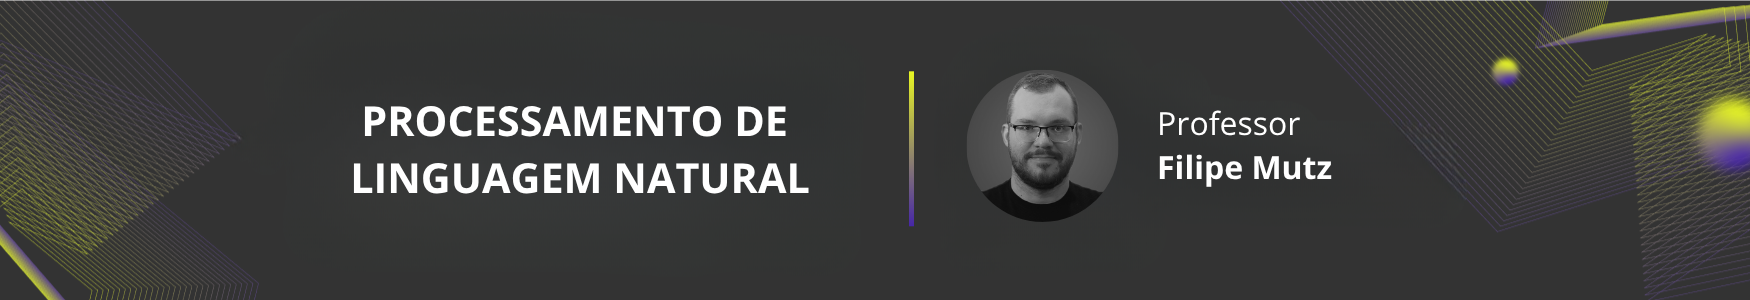

# 📝🤖 Word Embeddings


Os próximos métodos de PLN que vamos estudar são métodos de aprendizado baseado em sequências (*sequence learning*). Diferente do BoW, eles são capazes de processar o texto como uma **sequência de unidades textuais** (caracteres, palavras ou subpalavras), isto é, como um termos em uma determinada **ordem**.

Na primeira semana, estudamos o processo de **tokenização** que é capaz de dividir textos em partes menores e atribuir um índice inteiro à cada unidade textual. Os **Word embeddings** dão um passo além e transformam palavras em **vetores numéricos** de tamanho fixo. Estes vetores são construídos de forma que palavras/tokens com significado parecido sejam mapeados em vetores próximos no espaço, mesmo se escritos de forma completamente diferente. Assim, dado um texto, os tokens são extraídos, transformados em *word embeddings* e a sequência de vetores é usada como entrada para os algoritmos de aprendizado de sequências.


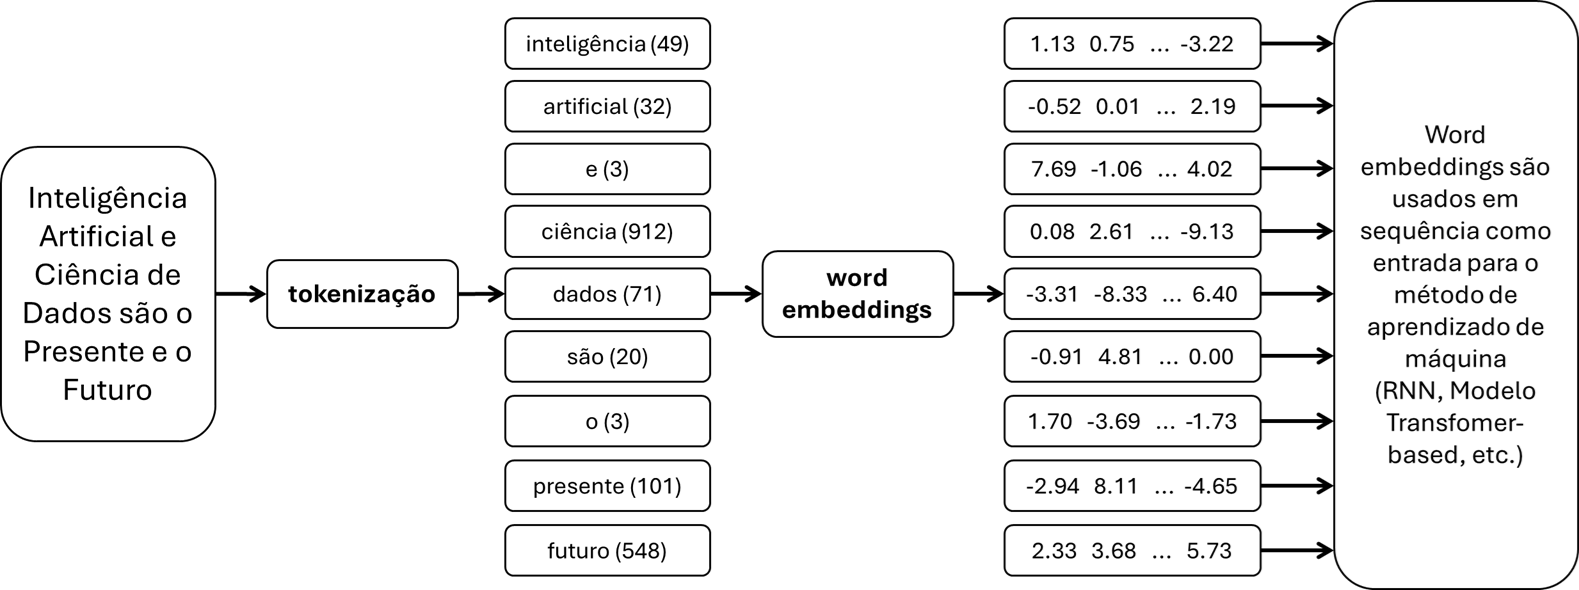


## Métodos para Construção de *Word Embeddings*


Os métodos para construção de *word embeddings* tipicamente partem da hipótese que **palavras possuem significados parecidos se aparecem em  contextos semelhantes, isto é, com as mesmas palavras ao redor**.

**Exemplo:** Nomes de times de futebol possuem similaridade semântica por serem adequados para preencher as lacunas nas frases abaixo.

- *"A camisa de futebol mais bonita do mundo é a do ________."*
- *"O time do ________ venceu o time do ________ na partida de sábado."*
- *"O título do campeonato foi conquistado pelo ________."*

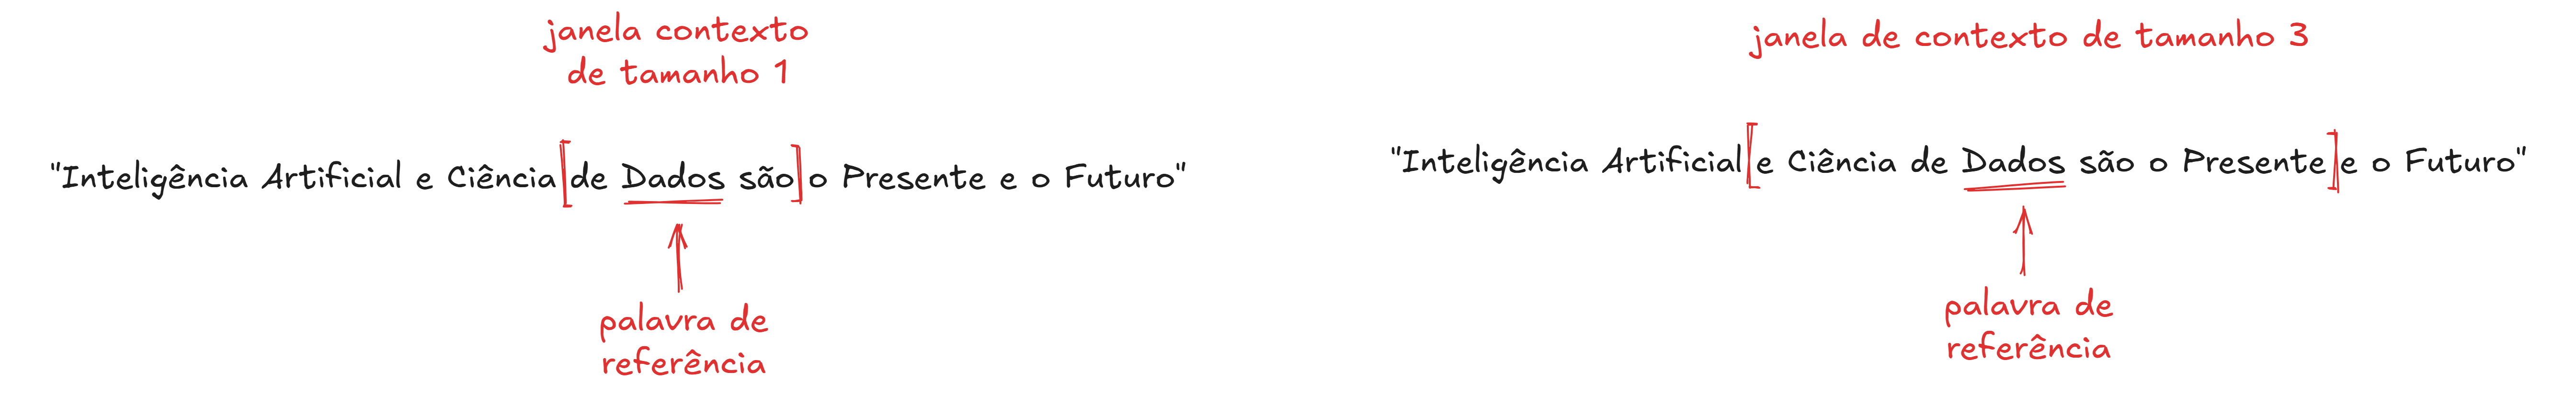

**Modelos baseados em Predição (e.g., Word2Vec)**

* **Continuous Bag-of-Words (CBoW)**: Aprendem os *embeddings* tentando prever a palavra de referência a partir de seu contexto.

* **Skip-gram**: Faz o inverso e aprende os *embeddings* tentando prever as palavras do contexto usando a palavra de referência.


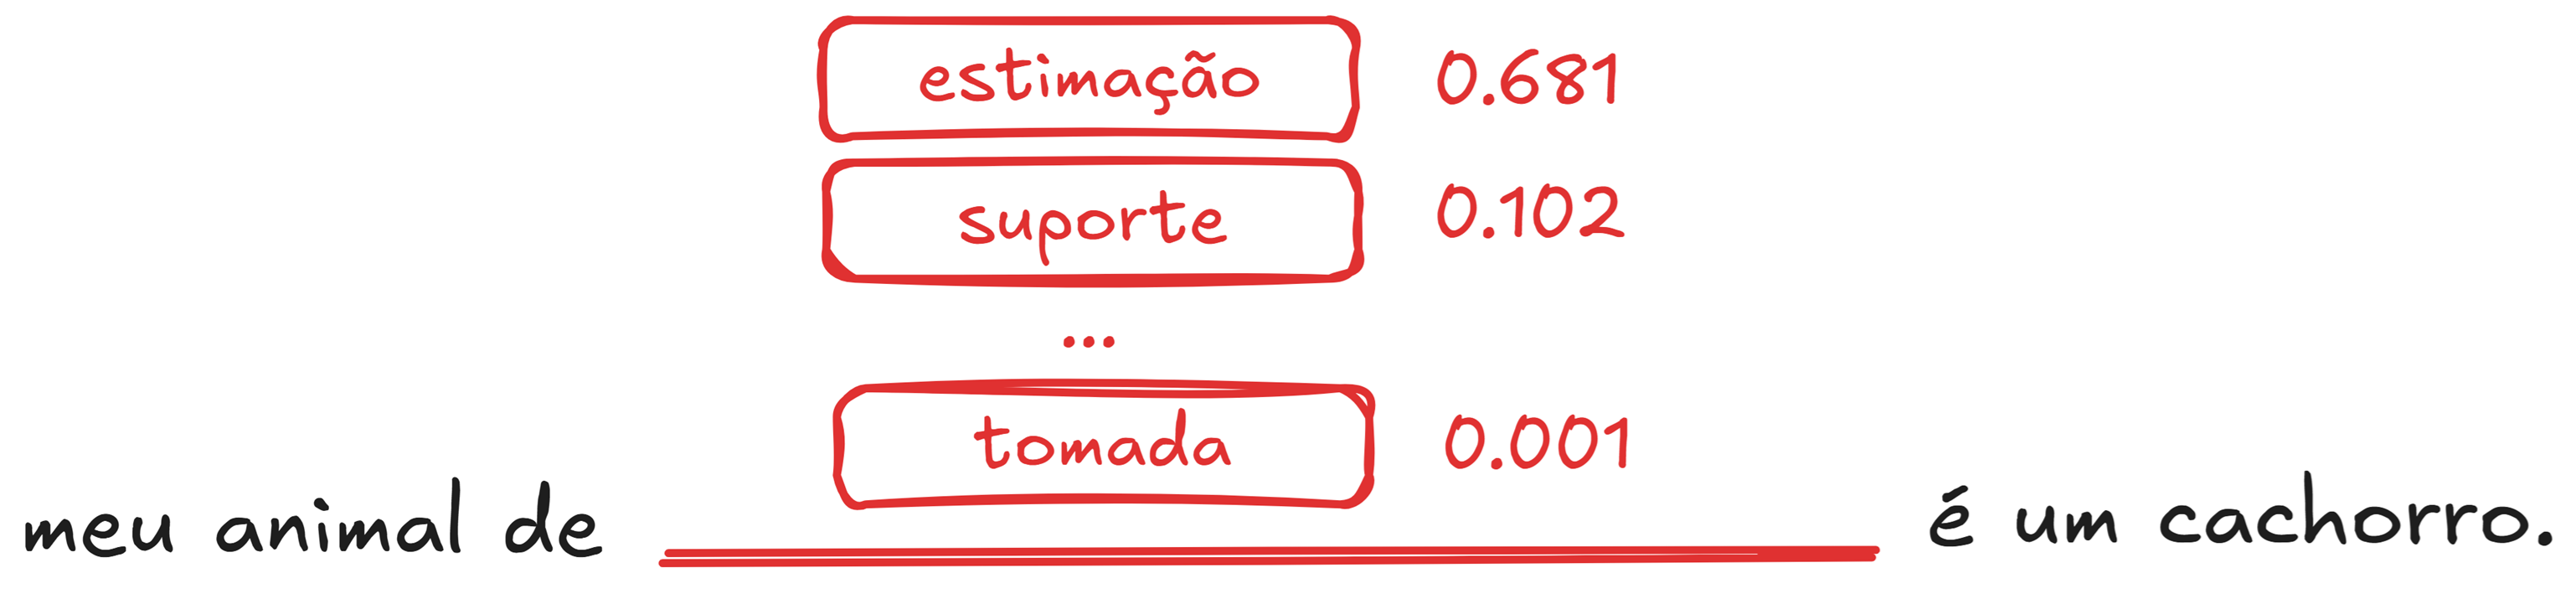

**Modelos baseados em Contagem (e.g., GloVe)**: Utilizam estatísticas globais do corpus, como a frequência de coocorrência de palavras e tokens em janelas de contexto para aprender os *embeddings*.

**Modelos "Task-Specific"**: Em algumas arquiteturas recentes, *embeddings* são aprendidos juntamente com os demais parâmetros do modelo durante o treinamento, sem a necessidade de uma etapa separada *a priori*. Estes *embeddings* são **otimizados para maximizar a performance na tarefa em questão**.

**Modelos baseados em Linguagem Contextualizada**: Diferentemente dos modelos anteriores, que atribuem um único vetor a cada palavra, os modelos modernos — como **BERT**, **GPT** e outros LLMs (*Large Language Models*) — produzem *embeddings* que variam conforme o contexto em que a palavra aparece. Por exemplo, a palavra "mangas" terá vetores diferentes em "comi duas mangas" e "arregacei as mangas e comecei a trabalhar".



## *Word embeddings* pré-treinados



Existem diversos outros métodos para criação de *word embedding* como *skip-gram*, GloVe e FastText [ALM19, WAN20].

A biblioteca `gensim` provê implementações de diversos métodos para construção de *word embeddings*, quanto modelos de *word embeddings* pré-treinados usando bases de dados de larga escala. Quanto maior a base de dados utilizada no treinamento, mais padrões de uso dos termos serão aprendidas pelos *word embeddings*.


Use o comando abaixo para instalar a biblioteca `gensim`.

In [ ]:
!python -m pip install gensim

Os modelos existentes na biblioteca podem ser vistos [neste link](https://github.com/piskvorky/gensim-data?tab=readme-ov-file#models) ou usando o comando abaixo em um script python. Os números ao final dos nomes indicam a dimensionalidade dos *word embeddings*.

In [ ]:
import gensim.downloader

list(gensim.downloader.info()['models'].keys())

['fasttext-wiki-news-subwords-300',
 'conceptnet-numberbatch-17-06-300',
 'word2vec-ruscorpora-300',
 'word2vec-google-news-300',
 'glove-wiki-gigaword-50',
 'glove-wiki-gigaword-100',
 'glove-wiki-gigaword-200',
 'glove-wiki-gigaword-300',
 'glove-twitter-25',
 'glove-twitter-50',
 'glove-twitter-100',
 'glove-twitter-200',
 '__testing_word2vec-matrix-synopsis']

No curso, vamos utilizar o modelo `glove-twitter-50` por apresentar um bom *trade-off* entre custo computacional e qualidade dos *embeddings*. As células abaixo fazem o download do modelo e mostram como obter o *word embedding* de um termo e como buscar os termos mais similares a outros.

In [ ]:
glove_vectors = gensim.downloader.load('glove-twitter-50')

[==================================================] 100.0% 199.5/199.5MB downloaded


In [ ]:
embedding = glove_vectors['computador']
embedding

array([ 5.0599e-01, -2.9387e-01, -5.9358e-01, -2.6763e-01, -3.7652e-01,
       -5.0599e-02, -2.3308e-01, -1.0927e+00,  6.4846e-01, -5.9309e-01,
        2.4672e-01, -3.3852e-01, -3.2041e-01,  6.7158e-02, -8.8692e-01,
       -6.7118e-01, -3.1050e-01, -2.5613e-01,  4.7955e-04, -1.0491e+00,
       -6.2485e-01,  4.2897e-01,  2.6246e-01, -2.8833e-01, -6.4030e-01,
       -1.9526e+00, -7.5087e-02, -4.3035e-02,  4.7154e-01,  1.4329e+00,
       -2.2267e-01, -9.5768e-01, -1.1655e-01, -1.5614e+00, -1.2723e+00,
       -1.2228e-01,  3.6655e-01, -1.1384e+00, -1.8805e+00,  4.8224e-02,
       -9.6045e-01,  1.2337e+00, -8.9174e-01, -1.3951e+00,  1.7954e-01,
        9.1536e-02, -4.2366e-01,  8.2208e-01, -5.5840e-01, -3.7422e-01],
      dtype=float32)

In [ ]:
glove_vectors.most_similar('computador')

[('celular', 0.8722977638244629),
 ('telefone', 0.826638400554657),
 ('teclado', 0.8233320713043213),
 ('quarto', 0.8074617981910706),
 ('banheiro', 0.7734651565551758),
 ('ventilador', 0.7709875106811523),
 ('desligar', 0.7702875137329102),
 ('desliga', 0.7570242285728455),
 ('baixo', 0.7447758913040161),
 ('telemóvel', 0.7414283752441406)]

In [ ]:
glove_vectors.most_similar('science')

[('research', 0.8784608244895935),
 ('psychology', 0.8778603672981262),
 ('physics', 0.8762426376342773),
 ('studies', 0.8606525659561157),
 ('economics', 0.8509784936904907),
 ('biology', 0.8496463894844055),
 ('philosophy', 0.8453919887542725),
 ('history', 0.8399311900138855),
 ('geography', 0.836532711982727),
 ('education', 0.8354517221450806)]

In [ ]:
glove_vectors.most_similar('cachorro')

[('gato', 0.863291323184967),
 ('filhote', 0.8191294074058533),
 ('macaco', 0.8129260540008545),
 ('menino', 0.8069179058074951),
 ('filho', 0.8031520843505859),
 ('bicho', 0.800940752029419),
 ('urso', 0.7989080548286438),
 ('cão', 0.796929121017456),
 ('garoto', 0.7909190654754639),
 ('homem', 0.7847493290901184)]

Nem todas as palavras existem na base de *word embeddings*, então para evitar exceções é sempre importante verificar se o termo existe antes de acessar seu *word embedding*.

In [ ]:
'paralelepipedo' in glove_vectors

False

A célula abaixo mostra como codificar as palavras de uma frase em seus *word embeddings*. Note que poderíamos realizar preprocessamentos como remover *stop words*.

In [ ]:
import numpy as np

text = "inteligência artificial e ciência de dados"
words = text.split()
embds = np.array([glove_vectors[w] for w in words if w in glove_vectors])

embds.shape

(6, 50)

O gráfico abaixo mostra a distribuição de vários *word embeddings* no espaço. O método T-SNE [MAA08] é utilizado para projetar os pontos para o espaço 2D mantendo relações de distância entre eles.

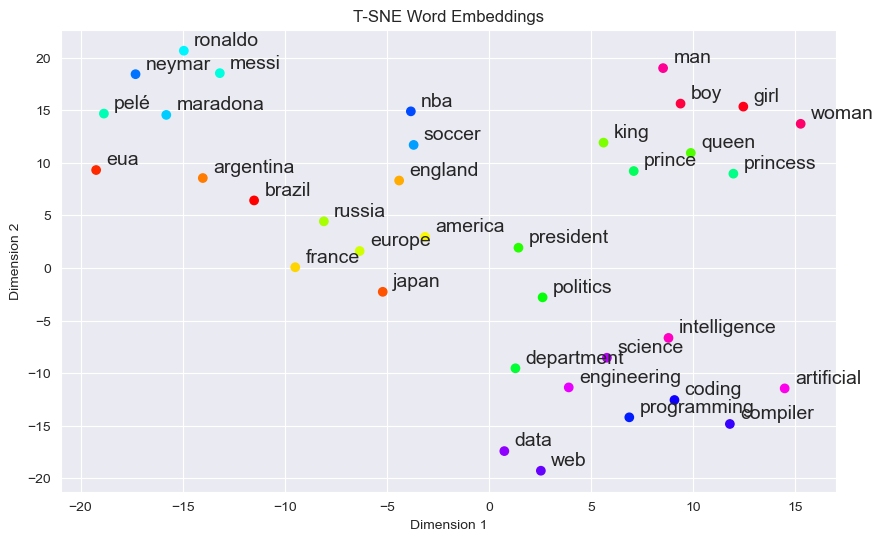

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

sns.set_style('darkgrid')


def plot_tsne(words, embds):
    tsne = TSNE(n_components=2, perplexity=10)
    vec2d = tsne.fit_transform(embds)

    plt.scatter(vec2d[:, 0], vec2d[:, 1], c=range(len(words)), cmap='hsv')

    for w, (x, y) in zip(words, vec2d):
        plt.text(x + 0.5, y + 0.5, w, fontsize=14)

    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.title(f"T-SNE Word Embeddings")


words = [
    'brazil', 'eua', 'japan', 'argentina', 'england', 'france', 'america', 'europe', 'russia',
    'king', 'queen', 'president', 'politics', 'department', 'prince', 'princess',
    'pelé', 'messi', 'ronaldo', 'maradona', 'soccer', 'neymar', 'nba',
    'programming', 'coding', 'compiler', 'web',
    'data', 'science', 'engineering', 'artificial', 'intelligence',
    'man', 'woman', 'boy', 'girl'
]

embds = np.array([glove_vectors[w] for w in words if w in glove_vectors])

plt.close('all')
plt.figure(figsize=(10, 6))
plot_tsne(words, embds)
plt.show()


## Referências



[ALM19] Almeida, F., & Xexéo, G. (2019). Word embeddings: A survey. arXiv preprint arXiv:1901.09069.

[WAN20] Wang, S., Zhou, W., & Jiang, C. (2020). A survey of word embeddings based on deep learning. Computing, 102(3), 717-740.

[MAA08] Maaten, L. V. D., & Hinton, G. (2008). Visualizing data using t-SNE. Journal of machine learning research, 9(Nov), 2579-2605.

[FON21] Fonseca, Camilla. “Word Embedding: Fazendo o Computador Entender o Significado Das Palavras.” Turing Talks, 23 Jan. 2021, https://medium.com/turing-talks/word-embedding-fazendo-o-computador-entender-o-significado-das-palavras-92fe22745057.

[DOS19] Doshi, Sanket. “Skip-Gram: NLP Context Words Prediction Algorithm.” Medium, 17 Mar. 2019, https://towardsdatascience.com/skip-gram-nlp-context-words-prediction-algorithm-5bbf34f84e0c

[W&B24] “Weights & Biases.” W&B, https://wandb.ai/authors/embeddings-2/reports/An-Introduction-to-the-Global-Vectors-GloVe-Algorithm--VmlldzozNDg2NTQ. Accessed 14 Aug. 2024
